In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

How much is my car worth? A methodology for predicting used cars prices using Random Forest

Nabarun Pal, Priya Arora, Dhanasekar Sundararaman, Puneet Kohli, Sai Sumanth Palakurthy


Cars are being sold more than ever. Developing countries adopt the lease culture instead of buying a new car due to affordability. Therefore, the rise of used cars sales is exponentially increasing. Car sellers sometimes take advantage of this scenario by listing unrealistic prices owing to the demand. Therefore, arises a need for a model that can assign a price for a vehicle by evaluating its features taking the prices of other cars into consideration. In this paper, we use supervised learning method namely Random Forest to predict the prices of used cars. The model has been chosen after careful exploratory data analysis to determine the impact of each feature on price. A Random Forest with 500 Decision Trees were created to train the data. From experimental results, the training accuracy was found out to be 95.82%, and the testing accuracy was 83.63%. The the model can predict the price of cars accurately by choosing the most correlated features.

https://arxiv.org/abs/1711.06970


In [ ]:
#Load Dataset

df = pd.read_csv("Downloads/car_price_prediction_ (1).csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


This article demonstrates that by using methods such as Extreme Gradient Boosting (XGBoost), dummy variables, etc., the selling price can be accurately predicted according to the different conditions and variables of each used car. The used car dataset is divided into a training dataset and a test dataset according to the ratio of 83% and 17%. This article uses a total of three data processing methods to find the most accurate prediction method. The first is to remove the outliers of the training dataset and test dataset, and then directly use the xgboost prediction method for prediction. The second is to remove the outliers and remove the variable power that is most closely related to the price of the used car, and then use the xgboost prediction method to make predictions. The third method is to remove outliers and then normalize the training dataset and test dataset, finally using the xgboost prediction method to predict. The experimental results show that normalizing the dataset and then using XGBoost and dummy variables can be used to predict the selling price accurately and efficiently through the different usage conditions of each used car.

https://www.researchgate.net/publication/370589503_Used_Car_Price_Prediction_by_Using_XGBoost

Prior research demonstrates that ensemble machine learning methods such as Random Forest, Gradient Boosting, and XGBoost outperform traditional regression approaches for used car price prediction due to their ability to capture nonlinear relationships and complex feature interactions. Feature engineering and preprocessing have also been shown to significantly improve predictive performance.

In [ ]:
#Dataset Overview
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


Abstract

In this paper, we investigate the application of supervised machine learning techniques to predict the price of used cars in Mauritius. The predictions are based on historical data collected from daily newspapers. Different techniques like multiple linear regression analysis, k-nearest neighbours, naïve bayes and decision trees have been used to make the predictions. The predictions are then evaluated and compared in order to find those which provide the best performances. A seemingly easy problem turned out to be indeed very difficult to resolve with high accuracy. All the four methods provided comparable performance. In the future, we intend to use more sophisticated algorithms to make the predictions.

https://www.academia.edu/105214483/Prediction_of_Used_Car_Prices_Using_Artificial_Neural_Networks_and_Machine_Learning

In [ ]:
#Statistical Summary
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [ ]:
#Missing Values Analysis
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

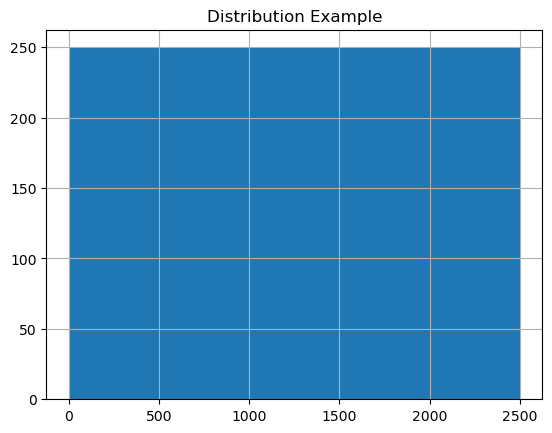

In [ ]:
#EDA: Distributions
num_cols = df.select_dtypes(include=np.number).columns
plt.figure()
df[num_cols[0]].hist()
plt.title("Distribution Example")
plt.show()

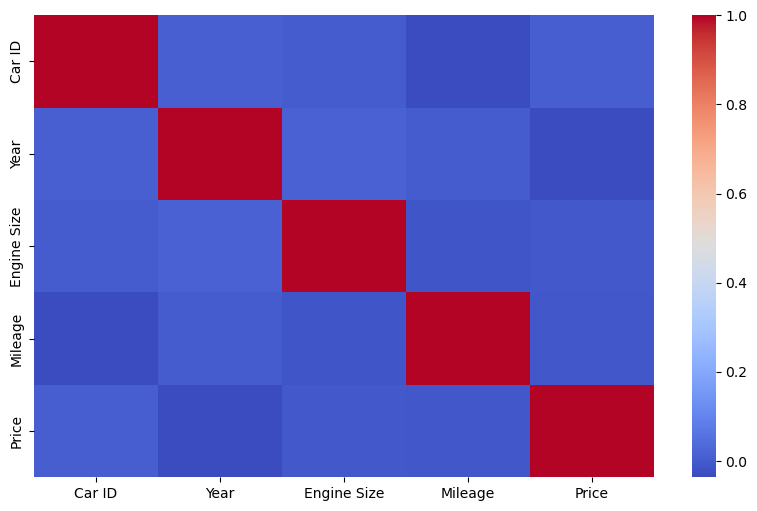

In [ ]:
#EDA: Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [ ]:
#Data Preprocessing & Encoding

from sklearn.preprocessing import LabelEncoder

df_p = df.copy()
for col in df_p.select_dtypes(include="object"):
    df_p[col] = LabelEncoder().fit_transform(df_p[col])

df_p.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,5,2016,2.3,3,1,114832,1,26613.92,19
1,2,1,2018,4.4,1,1,143190,2,14679.61,1
2,3,0,2013,4.5,1,1,181601,1,44402.61,3
3,4,5,2011,4.1,0,0,68682,1,86374.33,20
4,5,2,2009,2.6,0,1,223009,0,73577.10,21


In [ ]:
#Feature-Target Split

X = df_p.drop(df_p.columns[-1], axis=1)
y = df_p[df_p.columns[-1]]

In [ ]:
#Train - Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#ML Model: Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

mean_squared_error(y_test, rf_preds)

56.58295639999999

In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [ ]:
#ML Model: XGBoost

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

mean_squared_error(y_test, xgb_preds)

71.69465637207031

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 10139385.0000    
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 89563.4688  
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24808.6445  
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13866.6211  
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10987.6582 
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10337.7061  
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9945.6992 
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9836.4492  
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7931.9336 
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8397.8594  


In [ ]:
# Deep Learning Evaluation

from sklearn.metrics import mean_squared_error

dl_preds = model.predict(X_test)
mean_squared_error(y_test, dl_preds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


11158.74609375

In [ ]:
# Model Comparison

results = {
    "RandomForest_MSE": mean_squared_error(y_test, rf_preds),
    "XGBoost_MSE": mean_squared_error(y_test, xgb_preds),
    "DeepLearning_MSE": mean_squared_error(y_test, dl_preds)
}
results


{'RandomForest_MSE': 56.58295639999999,
 'XGBoost_MSE': 71.69465637207031,
 'DeepLearning_MSE': 11158.74609375}